# Phase 5 : EDA analytique

Projet final Machine Learning, blocs 6 et 8.

## Objectif de ce notebook

La phase 2 cherchait des problèmes. Celle-ci cherche des réponses. Le jeu de données est
maintenant propre et enrichi, et les cinq questions business posées au cadrage attendent
chacune un chiffre, une interprétation et une recommandation.

## Deux règles de méthode

**Première règle : tout se calcule sur le seul jeu d'entraînement, saisons 2022 à 2025.**

La saison 2026 est le jeu de test. Le guide autorise une seule lecture, à la toute fin de la
phase 7. La dépenser ici, pour une question exploratoire, reviendrait à choisir des variables
et des hypothèses en fonction de résultats que le modèle sera ensuite censé découvrir seul.
Le score final ne mesurerait plus rien.

C'est la même logique que la fuite de données, appliquée à l'analyste plutôt qu'au code.

**Seconde règle : un pourcentage sans effectif ne veut rien dire.**

Un taux de victoire de 56 % sur 80 parties et un taux de 56 % sur 8 000 parties se ressemblent
dans un tableau et n'ont pas la même valeur. Chaque taux produit ici est accompagné de son
effectif et de son intervalle de confiance à 95 %, calculés par `src/analyse.py`. Quand
l'intervalle contient 50 %, la bonne conclusion est qu'il n'y a rien à conclure.

## Le fil conducteur des analyses

La plupart des questions de ce projet sont des questions de contribution : est-ce que X apporte
quelque chose **au-delà** de l'avantage économique, qui est de très loin le premier signal ?

Une corrélation brute ne peut pas y répondre. Le premier sang est corrélé à la victoire, mais
il rapporte 400 or à celui qui l'obtient : sa corrélation peut n'être que le reflet de cet or,
déjà présent dans `golddiffat15`.

La méthode employée ici est donc systématiquement la même : **comparer à avantage économique
égal**, en restreignant l'analyse aux parties où les deux équipes sont au coude à coude à la
minute 15. Dans cette bande, l'or n'explique plus rien, et ce qui reste est un apport propre.

## Livrables

Les réponses aux cinq questions business de `docs/00_cadrage.md`, la synthèse exportée dans
`docs/rapport_analytique.md`, et cinq figures dans `figures/`.

Données fournies par Oracle's Elixir (Tim Sevenhuysen, oracleselixir.com).

## 0. Chargement et périmètre d'analyse

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import analyse, config

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

PALETTE = config.PALETTE
plt.rcParams.update({
    "figure.facecolor": PALETTE["background"],
    "axes.facecolor": PALETTE["background"],
    "axes.edgecolor": PALETTE["secondary"],
    "axes.labelcolor": PALETTE["primary"],
    "text.color": PALETTE["primary"],
    "xtick.color": PALETTE["secondary"],
    "ytick.color": PALETTE["secondary"],
    "grid.color": PALETTE["grid"],
    "font.size": 10,
    # La grille passe derriere les barres, sinon elle les raye.
    "axes.axisbelow": True,
})
config.FIGURES.mkdir(parents=True, exist_ok=True)


def fr(nombre):
    """Separateur de milliers francais : espace, pas virgule."""
    return f"{nombre:,}".replace(",", " ")


donnees = pd.read_parquet(config.DATA_PROCESSED / "lol_at15.parquet")

# Le perimetre d'analyse. Tout le notebook travaille sur `train`, jamais sur `donnees`.
train = donnees[donnees["date"] < config.SPLIT_DATE].copy()
n_test = int((donnees["date"] >= config.SPLIT_DATE).sum())

print(f"Dataset complet   : {len(donnees):,} lignes")
print(f"Perimetre analyse : {len(train):,} lignes, "
      f"{train['gameid'].nunique():,} parties, "
      f"{train['date'].min():%Y-%m-%d} au {train['date'].max():%Y-%m-%d}")
print(f"Reserve de test   : {n_test:,} lignes, non ouvertes dans ce notebook")
print()
print(f"Cible equilibree a {100 * train['result'].mean():.2f} %")
print(f"Ligues : {train['league'].nunique()} | regions : {train['region'].nunique()} "
      f"| patchs : {train['patch'].nunique()}")

Dataset complet   : 92,616 lignes
Perimetre analyse : 76,070 lignes, 38,035 parties, 2022-01-10 au 2025-12-29
Reserve de test   : 16,546 lignes, non ouvertes dans ce notebook

Cible equilibree a 50.00 %
Ligues : 77 | regions : 9 | patchs : 90


Le périmètre est confortable : plus de 38 000 parties sur quatre saisons. La cible reste
parfaitement équilibrée à 50 %, ce qui simplifie toute la lecture qui suit. Un taux de victoire
supérieur à 50 % dans un sous-groupe est un écart par rapport au hasard, sans avoir besoin de
corriger quoi que ce soit.

## 1. Question business 1 : quels avantages pèsent le plus à la minute 15 ?

### Reformulation

Parmi les avantages observables à la minute 15, l'or, l'expérience, les sbires, les kills et
les objectifs neutres, lesquels sont le plus associés à la victoire, et surtout lesquels
apportent une information **qui n'est pas déjà contenue dans l'écart d'or** ?

- Métrique nécessaire : taux de victoire, AUC univariée, écart de taux à or égal
- Granularité : une ligne équipe dans une partie
- Analyse : classement univarié, puis analyse de contribution à avantage économique contrôlé

### 1.1 Classement brut des avantages

In [2]:
AVANTAGES = ["golddiffat15", "xpdiffat15", "csdiffat15", "diff_kills_at15",
             "deathsat15", "objectifs_precoces", "firstblood", "firstdragon",
             "firstherald", "ecart_or_normalise"]

classement = analyse.pouvoir_discriminant(train, AVANTAGES)
classement["auc_univarie"] = classement["auc_univarie"].round(3)
classement["correlation"] = classement["correlation"].round(3)
classement["manquant_pct"] = classement["manquant_pct"].round(2)
print(classement.to_string(index=False))

           feature  auc_univarie  correlation    sens  manquant_pct
ecart_or_normalise         0.820        0.534 positif          2.36
      golddiffat15         0.820        0.533 positif          0.00
        xpdiffat15         0.792        0.494 positif          0.00
   diff_kills_at15         0.763        0.449 positif          0.00
        csdiffat15         0.748        0.430 positif          0.00
objectifs_precoces         0.679        0.327 positif          0.00
        deathsat15         0.651       -0.271 negatif          0.00
       firstherald         0.615        0.229 positif          0.00
        firstblood         0.599        0.199 positif          0.00
       firstdragon         0.585        0.171 positif          0.00

L'écart d'or domine, à 0,82 d'AUC. Les trois écarts suivants, expérience, kills et sbires,
mesurent la même domination par d'autres canaux et arrivent juste derrière. Les objectifs
neutres pris un par un sont nettement en dessous, entre 0,58 et 0,61.

Ce classement est celui qu'on lit habituellement, et il est trompeur. Il ne dit pas si un
objectif apporte quelque chose au-delà de l'or, il dit seulement qu'il est associé à la
victoire. Or trois de ces objectifs rapportent de l'or.

### 1.2 La courbe de conversion de l'écart d'or

In [3]:
pente, courbe = analyse.pente_or(train)
or_par_point = 0.01 / pente

print(f"Pente locale : {100 * pente * 1000:.2f} points de taux de victoire pour 1 000 or")
print(f"Soit environ {or_par_point:.0f} or pour gagner un point de taux de victoire")
print()
print(courbe[["effectif", "taux", "ic_bas", "ic_haut", "milieu"]].round(4).to_string())

Pente locale : 13.64 points de taux de victoire pour 1 000 or
Soit environ 73 or pour gagner un point de taux de victoire

                effectif    taux  ic_bas  ic_haut  milieu
_tranche                                                 
(-1500, -1250]      2442  0.3137  0.2956   0.3324 -1375.0
(-1250, -1000]      2556  0.3408  0.3226   0.3594 -1125.0
(-1000, -750]       2660  0.3865  0.3681   0.4051  -875.0
(-750, -500]        2813  0.4170  0.3989   0.4353  -625.0
(-500, -250]        2799  0.4491  0.4307   0.4676  -375.0
(-250, 0]           2849  0.4735  0.4552   0.4919  -125.0
(0, 250]            2847  0.5262  0.5078   0.5445   125.0
(250, 500]          2804  0.5506  0.5322   0.5690   375.0
(500, 750]          2815  0.5833  0.5650   0.6014   625.0
(750, 1000]         2655  0.6147  0.5960   0.6330   875.0
(1000, 1250]        2559  0.6604  0.6418   0.6785  1125.0
(1250, 1500]        2439  0.6855  0.6668   0.7036  1375.0


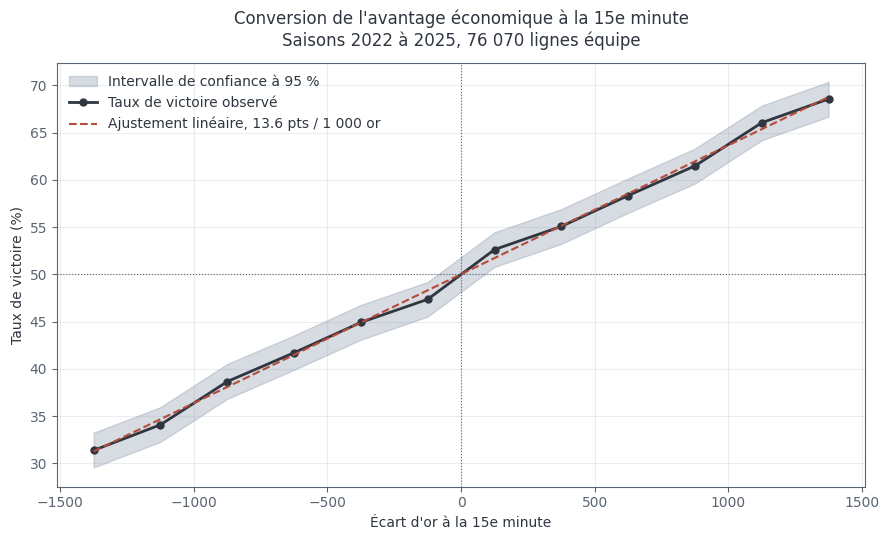

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.fill_between(courbe["milieu"], 100 * courbe["ic_bas"], 100 * courbe["ic_haut"],
                color=PALETTE["accent"], alpha=0.35,
                label="Intervalle de confiance à 95 %")
ax.plot(courbe["milieu"], 100 * courbe["taux"], marker="o", color=PALETTE["primary"],
        linewidth=2, markersize=5, label="Taux de victoire observé")

ajustement = np.polyval(np.polyfit(courbe["milieu"], courbe["taux"], 1), courbe["milieu"])
ax.plot(courbe["milieu"], 100 * ajustement, linestyle="--", color=PALETTE["highlight"],
        linewidth=1.5, label=f"Ajustement linéaire, {100 * pente * 1000:.1f} pts / 1 000 or")

ax.axhline(50, color=PALETTE["secondary"], linewidth=0.8, linestyle=":")
ax.axvline(0, color=PALETTE["secondary"], linewidth=0.8, linestyle=":")
ax.set_xlabel("Écart d'or à la 15e minute")
ax.set_ylabel("Taux de victoire (%)")
ax.set_title("Conversion de l'avantage économique à la 15e minute\n"
             f"Saisons 2022 à 2025, {fr(len(train))} lignes équipe", pad=12, fontsize=12)
ax.grid(True, alpha=0.5)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig(config.FIGURES / "05_conversion_ecart_or.png", dpi=150,
            facecolor=PALETTE["background"])
plt.show()

La relation est presque linéaire dans la bande centrale, ce qui autorise une lecture simple :
sur cet intervalle, **1 000 or d'avance à la 15e minute valent environ 13,6 points de taux de
victoire**. C'est cette pente qui va servir de convertisseur dans la section suivante.

Hors de la bande, la courbe sature, comme attendu : au-delà de 5 000 or d'avance, la partie
est presque jouée et 1 000 or de plus ne changent plus grand-chose. C'est précisément pour
cela que la pente est ajustée sur la bande centrale et pas sur l'ensemble.

### 1.3 Ce que vaut réellement un objectif, à or égal

L'idée de la mesure. On se restreint aux parties où l'écart d'or à 15 minutes est inférieur à
250 en valeur absolue : les deux équipes sont au coude à coude, et l'or n'explique plus rien.

Dans cette bande, l'écart de taux de victoire entre l'équipe qui a pris l'objectif et celle qui
ne l'a pas pris est ce que l'objectif apporte **en plus** de l'or qu'il a déjà rapporté. La
pente mesurée juste au-dessus permet ensuite de traduire cet écart en or, ce qui donne une
unité que tout le monde comprend dans un vestiaire.

Le test est mécaniquement lisible :

- le premier sang rapporte 400 or à celui qui tue, cet or est donc déjà dans `golddiffat15`,
  et l'objectif devrait valoir zéro dans cette mesure ;
- le premier héraut se transforme en plaques et en or, même raisonnement ;
- le premier dragon ne rapporte aucun or, seulement un bonus permanent qui se cumule. S'il vaut
  quelque chose, cela doit apparaître ici et nulle part ailleurs.

In [5]:
valeurs = pd.DataFrame([
    analyse.valeur_en_or(train, objectif, pente)
    for objectif in config.EARLY_OBJECTIVES
])
valeurs["significatif"] = np.where(valeurs["p_valeur"] < 0.05, "oui", "non")

affichage = valeurs.assign(
    taux_avec=lambda d: (100 * d["taux_avec"]).round(2),
    taux_sans=lambda d: (100 * d["taux_sans"]).round(2),
    ecart_points=lambda d: d["ecart_points"].round(2),
    or_equivalent=lambda d: d["or_equivalent"].round(0),
    p_valeur=lambda d: d["p_valeur"].map(lambda p: f"{p:.1e}"),
)
print("Parties au coude a coude, ecart d'or inferieur a 250 :")
print(affichage.to_string(index=False))

Parties au coude a coude, ecart d'or inferieur a 250 :
 indicateur  taux_avec  taux_sans  n_avec  n_sans  ecart_points p_valeur  or_equivalent significatif
 firstblood      50.19      49.81    2843    2845          0.39  7.7e-01           28.0          non
firstdragon      57.03      42.97    2844    2844         14.06  2.8e-26         1031.0          oui
firstherald      50.44      49.56    2837    2851          0.88  5.1e-01           64.0          non


Le résultat est net, et c'est le principal apport de ce notebook.

**Le premier dragon vaut environ 1 030 or.** À avantage économique égal, l'équipe qui l'a pris
gagne 57,0 % de ses parties contre 43,0 % pour l'autre, soit 14,1 points d'écart, avec une
p-valeur de l'ordre de 10 puissance moins 26. Il ne rapporte pourtant aucun or : ce qu'il
apporte est entièrement dans le bonus cumulatif et dans le contrôle de la carte qu'il implique.

**Le premier sang et le premier héraut ne valent rien de plus que l'or qu'ils rapportent.**
0,4 et 0,9 point d'écart, p-valeurs de 0,77 et 0,51 : à or égal, ces deux objectifs
n'apportent aucune information. Leur corrélation brute avec la victoire, 0,20 et 0,23, était
entièrement médiatisée par l'or, exactement comme la mécanique du jeu le laissait attendre.

C'est le type de résultat qu'une corrélation seule ne peut pas produire, et qui change une
consigne d'entraînement.

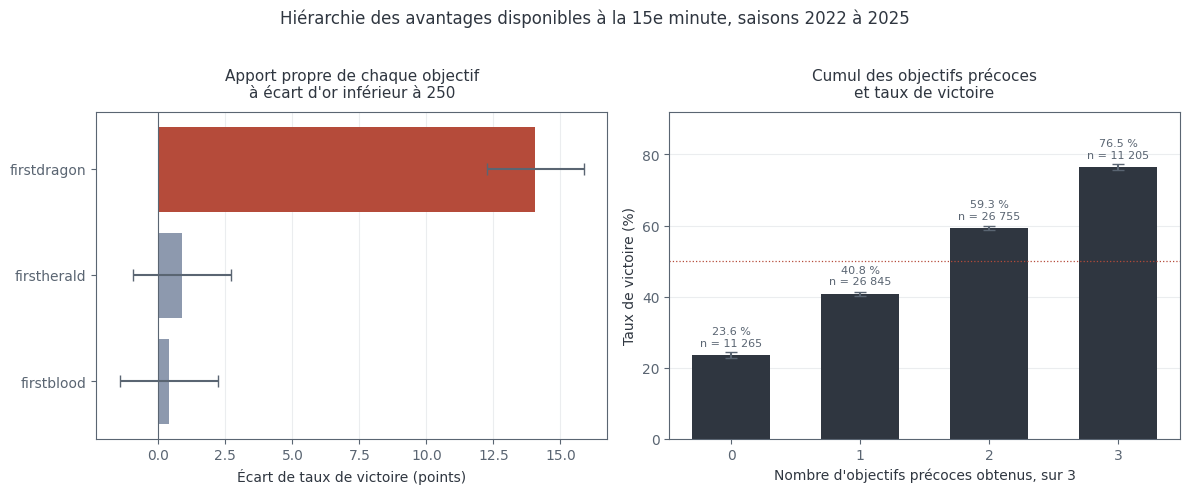

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
ordre = valeurs.sort_values("ecart_points")
couleurs = [PALETTE["highlight"] if s == "oui" else PALETTE["accent"]
            for s in ordre["significatif"]]
demi = [100 * (analyse.intervalle_wilson(int(round(t * n)), n)[1]
               - analyse.intervalle_wilson(int(round(t * n)), n)[0]) / 2
        for t, n in zip(ordre["taux_avec"], ordre["n_avec"])]
ax.barh(ordre["indicateur"], ordre["ecart_points"], color=couleurs,
        xerr=demi, error_kw={"ecolor": PALETTE["secondary"], "capsize": 4})
ax.axvline(0, color=PALETTE["secondary"], linewidth=0.8)
ax.set_xlabel("Écart de taux de victoire (points)")
ax.set_title("Apport propre de chaque objectif\nà écart d'or inférieur à 250",
             fontsize=11, pad=10)
ax.grid(True, axis="x", alpha=0.5)

ax = axes[1]
score = analyse.taux_victoire(train, "objectifs_precoces")
ax.bar(score.index.astype(str), 100 * score["taux"], color=PALETTE["primary"], width=0.6,
       yerr=100 * (score["ic_haut"] - score["ic_bas"]) / 2,
       error_kw={"ecolor": PALETTE["secondary"], "capsize": 4})
for x, (taux, effectif) in enumerate(zip(score["taux"], score["effectif"])):
    ax.text(x, 100 * taux + 2.5, f"{100 * taux:.1f} %\nn = {fr(effectif)}",
            ha="center", fontsize=8, color=PALETTE["secondary"])
ax.axhline(50, color=PALETTE["highlight"], linewidth=0.9, linestyle=":")
ax.set_ylim(0, 92)
ax.set_xlabel("Nombre d'objectifs précoces obtenus, sur 3")
ax.set_ylabel("Taux de victoire (%)")
ax.set_title("Cumul des objectifs précoces\net taux de victoire", fontsize=11, pad=10)
ax.grid(True, axis="y", alpha=0.5)

fig.suptitle("Hiérarchie des avantages disponibles à la 15e minute, saisons 2022 à 2025",
             fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(config.FIGURES / "05_valeur_objectifs_precoces.png", dpi=150,
            facecolor=PALETTE["background"], bbox_inches="tight")
plt.show()

### Insight, recommandation et confiance, question 1

**Insight.** L'écart d'or reste le meilleur indicateur isolé, à 0,82 d'AUC, et 1 000 or d'avance
valent 13,6 points de taux de victoire. Mais tous les objectifs précoces ne se valent pas : le
premier dragon apporte 14,1 points à avantage économique égal, soit l'équivalent de 1 030 or,
alors que le premier sang et le premier héraut n'apportent rien au-delà de l'or qu'ils
rapportent déjà.

**Recommandation.** Prioriser la contestation du premier dragon plutôt que la recherche du
premier sang. Un premier sang qui coûte une position sur la carte est un mauvais échange, alors
que 1 000 or dépensés à sécuriser un dragon sont rentables. Pour un affichage de plateforme, le
premier dragon mérite d'être exposé comme un indicateur à part entière, pas le premier sang.

**Confiance : élevée.** L'effet du dragon est mesuré sur 5 688 parties au coude à coude, avec
une p-valeur de 10 puissance moins 26. **Limite :** la bande à 250 or contrôle l'avantage
économique mais pas la qualité des équipes, et une équipe plus forte prend plus souvent le
dragon. Une partie de l'écart mesuré reflète donc un écart de niveau, pas seulement la valeur
du dragon.

## 2. Question business 2 : l'avantage du côté bleu existe-t-il encore ?

### Reformulation

Le côté bleu choisit en premier à la draft. Cet avantage historique est-il toujours mesurable
sur 2022 à 2025, et se comporte-t-il de la même façon selon la saison, le niveau de ligue et
la région ?

- Métrique : taux de victoire des lignes de côté bleu, avec intervalle de confiance
- Analyse : comparaison à la référence de 50 %, puis segmentation

In [7]:
bleu = train[train["side"] == "Blue"]
victoires = int(bleu["result"].sum())
ic_bas, ic_haut = analyse.intervalle_wilson(victoires, len(bleu))

print(f"Parties analysees : {len(bleu):,}")
print(f"Taux de victoire du cote bleu : {100 * bleu['result'].mean():.2f} %")
print(f"Intervalle de confiance a 95 % : [{100 * ic_bas:.2f} % ; {100 * ic_haut:.2f} %]")
print()
print("50 % est-il dans l'intervalle ?", "oui" if ic_bas <= 0.5 <= ic_haut else "non")
print(f"Avantage estime : {100 * (bleu['result'].mean() - 0.5):.2f} points")
print(f"Soit environ {(bleu['result'].mean() - 0.5) / pente:.0f} or d'avance equivalents")

Parties analysees : 38,035
Taux de victoire du cote bleu : 52.93 %
Intervalle de confiance a 95 % : [52.43 % ; 53.43 %]

50 % est-il dans l'intervalle ? non
Avantage estime : 2.93 points
Soit environ 215 or d'avance equivalents


In [8]:
par_saison = analyse.taux_victoire(bleu, "saison")
par_tier = analyse.taux_victoire(bleu, "tier_ligue")
par_region = analyse.taux_victoire(bleu, "region").sort_values("taux", ascending=False)

print("Cote bleu par saison")
print(par_saison.round(4).to_string())
print()
print("Cote bleu par niveau de ligue")
print(par_tier.round(4).to_string())
print()
print("Cote bleu par region")
print(par_region.round(4).to_string())

Cote bleu par saison
        effectif    taux  ic_bas  ic_haut  fiable
saison                                           
2022       10641  0.5230  0.5135   0.5325    True
2023        9371  0.5335  0.5233   0.5435    True
2024        8802  0.5287  0.5183   0.5392    True
2025        9221  0.5329  0.5227   0.5431    True

Cote bleu par niveau de ligue
            effectif    taux  ic_bas  ic_haut  fiable
tier_ligue                                           
1               5484  0.5275  0.5143   0.5407    True
2              17611  0.5295  0.5221   0.5369    True
3              14940  0.5297  0.5217   0.5377    True

Cote bleu par region
                effectif    taux  ic_bas  ic_haut  fiable
region                                                   
CEI                   16  0.5625  0.3318   0.7690   False
Europe             15729  0.5333  0.5255   0.5411    True
International        833  0.5330  0.4991   0.5667    True
Moyen-Orient         618  0.5324  0.4929   0.5714    True
Asie-Pac

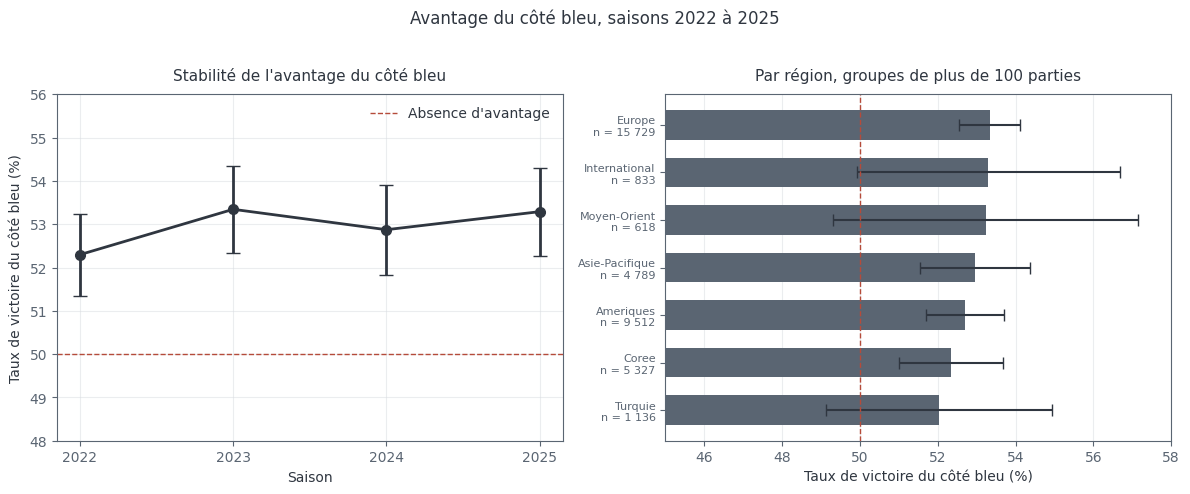

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
ax.errorbar(par_saison.index.astype(int), 100 * par_saison["taux"],
            yerr=100 * (par_saison["ic_haut"] - par_saison["ic_bas"]) / 2,
            marker="o", color=PALETTE["primary"], capsize=5, linewidth=2, markersize=7)
ax.axhline(50, color=PALETTE["highlight"], linewidth=1, linestyle="--",
           label="Absence d'avantage")
ax.set_xticks(par_saison.index.astype(int))
ax.set_ylim(48, 56)
ax.set_xlabel("Saison")
ax.set_ylabel("Taux de victoire du côté bleu (%)")
ax.set_title("Stabilité de l'avantage du côté bleu", fontsize=11, pad=10)
ax.grid(True, alpha=0.5)
ax.legend(frameon=False)

ax = axes[1]
regions = par_region[par_region["fiable"]]
y = np.arange(len(regions))
ax.barh(y, 100 * regions["taux"], color=PALETTE["secondary"], height=0.62,
        xerr=100 * (regions["ic_haut"] - regions["ic_bas"]) / 2,
        error_kw={"ecolor": PALETTE["primary"], "capsize": 4})
ax.set_yticks(y)
ax.set_yticklabels([f"{r}\nn = {fr(n)}" for r, n in zip(regions.index, regions["effectif"])],
                   fontsize=8)
ax.axvline(50, color=PALETTE["highlight"], linewidth=1, linestyle="--")
ax.set_xlim(45, 58)
ax.set_xlabel("Taux de victoire du côté bleu (%)")
ax.set_title("Par région, groupes de plus de 100 parties", fontsize=11, pad=10)
ax.grid(True, axis="x", alpha=0.5)
ax.invert_yaxis()

fig.suptitle("Avantage du côté bleu, saisons 2022 à 2025", fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(config.FIGURES / "05_avantage_cote_bleu.png", dpi=150,
            facecolor=PALETTE["background"], bbox_inches="tight")
plt.show()

### Insight, recommandation et confiance, question 2

**Insight.** L'avantage du côté bleu existe toujours et vaut 2,9 points de taux de victoire,
52,9 % contre 47,1 %, sur 38 035 parties. L'intervalle de confiance, de 52,4 % à 53,4 %, ne
contient pas 50 % : l'effet est réel et non un artefact d'échantillonnage. Converti avec la
pente de la question 1, cet avantage équivaut à environ 215 or d'avance offerts avant le début
de la partie.

Il est surtout **remarquablement stable** : entre 52,3 % et 53,4 % selon la saison, sans
tendance, et sans différence lisible entre les trois niveaux de ligue. Les intervalles de
confiance des quatre saisons se recoupent tous.

**Recommandation.** Traiter l'attribution du côté comme un paramètre fixe et non comme une
variable à corriger patch par patch. Deux points sur les trois de l'écart tiennent au premier
pick, ce qui justifie de préparer une stratégie de draft distincte selon le côté, mais pas de
révision saisonnière. Pour un modèle de prédiction, `side` est une variable à conserver, avec un
effet faible mais stable dans le temps, ce qui est exactement le profil qui traverse bien un
split chronologique.

**Confiance : élevée** sur le niveau global et sur la stabilité. **Limite :** la lecture par
région est fragile pour les régions peu représentées, et la Chine est quasi absente du jeu
d'entraînement, conséquence de la règle de complétude de la phase 3. Aucune conclusion régionale
ne peut en être tirée pour la LPL.

## 3. Question business 3 : la composition change-t-elle quelque chose, à or égal ?

### Reformulation

À avantage économique équivalent à la minute 15, une composition orientée tanks, ou un profil de
dégâts très physique, modifie-t-il la probabilité de victoire ?

- Analyse : segmentation à l'intérieur d'une bande d'écart d'or resserrée
- Contrôle indispensable : vérifier que l'écart d'or moyen est bien identique d'un groupe de
  composition à l'autre, sans quoi la bande ne contrôle rien

In [10]:
bande = train[train["golddiffat15"].abs() < 500].copy()
print(f"Bande a 500 or : {len(bande):,} lignes, "
      f"taux de victoire {100 * bande['result'].mean():.2f} %")
print()

COMPOS = ["compo_nb_tank", "compo_nb_mage", "compo_nb_marksman", "compo_nb_fighter"]
for colonne in COMPOS:
    table = analyse.taux_victoire(bande, colonne, effectif_minimum=300)
    table["or_moyen"] = bande.groupby(colonne)["golddiffat15"].mean().round(1)
    print(colonne)
    print(table.round(4).to_string())
    print()

Bande a 500 or : 11,286 lignes, taux de victoire 50.00 %

compo_nb_tank
               effectif    taux  ic_bas  ic_haut  fiable  or_moyen
compo_nb_tank                                                     
0                   709  0.4951  0.4584   0.5318    True       9.2
1                  3908  0.5046  0.4889   0.5203    True       2.8
2                  5046  0.4992  0.4854   0.5130    True       0.1
3                  1607  0.4960  0.4715   0.5204    True     -10.7
4                    16  0.2500  0.1018   0.4950   False     -62.4

compo_nb_mage
               effectif    taux  ic_bas  ic_haut  fiable  or_moyen
compo_nb_mage                                                     
0                   334  0.5060  0.4526   0.5592    True       1.4
1                  3788  0.4989  0.4830   0.5149    True      14.0
2                  5266  0.5066  0.4931   0.5201    True      -6.8
3                  1755  0.4838  0.4604   0.5072    True      -8.1
4                   143  0.4685  0.3886   

In [11]:
bande["profil_degats_q"] = pd.qcut(bande["profil_degats"], 4, duplicates="drop")
table_degats = analyse.taux_victoire(bande, "profil_degats_q", effectif_minimum=300)
table_degats["or_moyen"] = (
    bande.groupby("profil_degats_q", observed=True)["golddiffat15"].mean().round(1)
)
print("Profil de degats, quartiles de la part AD")
print(table_degats.round(4).to_string())
print()

morceaux = []
for c in COMPOS:
    table = analyse.taux_victoire(bande, c, effectif_minimum=300)
    table["or_moyen"] = bande.groupby(c)["golddiffat15"].mean()
    morceaux.append(table.assign(variable=c))

fiables = pd.concat(morceaux)
fiables = fiables[fiables["fiable"]]

ecart_max = 100 * (fiables["taux"] - 0.5).abs().max()
contiennent_50 = ((fiables["ic_bas"] <= 0.5) & (fiables["ic_haut"] >= 0.5)).mean()
# Verification du controle : si la bande fonctionne, l'or moyen doit etre proche de zero
# dans chaque groupe. Sinon on comparerait des groupes qui different aussi par l'or.
ecart_or_max = fiables["or_moyen"].abs().max()

print(f"Groupes de composition fiables : {len(fiables)}")
print(f"Ecart maximal a 50 % : {ecart_max:.2f} points")
print(f"Part des groupes dont l'intervalle contient 50 % : {100 * contiennent_50:.0f} %")
print(f"Controle : ecart d'or moyen le plus eloigne de zero : {ecart_or_max:.1f} or")

Profil de degats, quartiles de la part AD
                 effectif    taux  ic_bas  ic_haut  fiable  or_moyen
profil_degats_q                                                     
(-0.001, 0.667]      4576  0.4983  0.4838   0.5127    True      -6.4
(0.667, 0.75]        3818  0.4990  0.4831   0.5148    True       3.5
(0.75, 0.8]           175  0.4800  0.4072   0.5537   False      11.3
(0.8, 1.0]           2717  0.5057  0.4869   0.5245    True       5.1

Groupes de composition fiables : 13
Ecart maximal a 50 % : 2.83 points
Part des groupes dont l'intervalle contient 50 % : 100 %
Controle : ecart d'or moyen le plus eloigne de zero : 14.0 or


### Insight, recommandation et confiance, question 3

**Insight.** À avantage économique égal, la composition ne change rien de mesurable. Sur les
groupes de composition suffisamment peuplés, l'écart maximal au hasard est de 2,8 points, et
**tous les intervalles de confiance contiennent 50 %**. Le plus gros de ces écarts, les
compositions à trois combattants à 52,8 %, repose sur 547 parties et son intervalle va de
48,7 % à 57,0 % : il est parfaitement compatible avec le hasard.

Le contrôle tient, et il a été vérifié plutôt que supposé : dans chacun de ces groupes, l'écart
d'or moyen reste à moins de 15 or de zéro. La bande neutralise donc bien l'avantage économique,
et ce qui est comparé est bien la composition seule.

Ce résultat est cohérent avec la phase 4, où les cinq variables de composition affichaient une
AUC univariée comprise entre 0,50 et 0,51.

**Recommandation.** Ne pas arbitrer un ban ou un pick sur un comptage de tags. La valeur d'une
draft professionnelle réside dans la synergie entre champions et dans le contexte du patch, deux
choses qu'un comptage de tags ne capture pas. Pour le modèle, ces cinq variables sont à
conserver au premier tour, mais elles seront les premières candidates au retrait si la phase 7
montre qu'elles n'apportent rien en interaction.

**Confiance : moyenne.** Le résultat est solide en tant que résultat négatif sur cette mesure,
mais **la mesure elle-même est grossière**. Les tags de Data Dragon décrivent un champion sur
le patch courant, ils ignorent la synergie, le contexte du patch et l'ordre de la draft, absent
d'Oracle's Elixir. La conclusion à retenir est que **cette représentation de la composition**
n'apporte rien, pas que la composition n'a pas d'importance.

## 4. Question business 4 : une équipe en forme convertit-elle mieux son avance ?

### Reformulation

Une équipe qui gagne beaucoup depuis dix parties transforme-t-elle mieux une avance de 15
minutes qu'une équipe en difficulté ? Autrement dit, existe-t-il des équipes qui perdent des
parties gagnées ?

- Analyse : taux de victoire par tranche de forme, dans trois régimes de partie
- Piège à éviter : la forme récente est aussi un indicateur du niveau de l'équipe. Observer
  qu'une équipe en forme gagne plus ne dit rien sur sa capacité à **convertir**. Il faut
  comparer l'amplitude de l'effet entre les régimes, pas son existence.

In [12]:
TRANCHES = [0, 0.3, 0.5, 0.7, 1.0]
ETIQUETTES = ["moins de 30 %", "30 a 50 %", "50 a 70 %", "plus de 70 %"]

REGIMES = {
    "Partie équilibrée, |or| < 500": train[train["golddiffat15"].abs() < 500],
    "Avance, or > 1 000": train[train["golddiffat15"] > 1000],
    "Retard, or < -1 000": train[train["golddiffat15"] < -1000],
}

resultats_forme = {}
for nom, sous_ensemble in REGIMES.items():
    decoupe = pd.cut(sous_ensemble["forme_equipe_10_derniers"], TRANCHES,
                     labels=ETIQUETTES, include_lowest=True)
    table = analyse.taux_victoire(sous_ensemble.assign(forme=decoupe), "forme")
    resultats_forme[nom] = table
    amplitude = 100 * (table["taux"].iloc[-1] - table["taux"].iloc[0])
    print(f"{nom}  ({len(sous_ensemble):,} lignes)")
    print(table.round(4).to_string())
    print(f"  Amplitude entre la plus mauvaise et la meilleure forme : {amplitude:.1f} points")
    print()

Partie équilibrée, |or| < 500  (11,286 lignes)
               effectif    taux  ic_bas  ic_haut  fiable
forme                                                   
moins de 30 %      2420  0.4153  0.3958   0.4350    True
30 a 50 %          3775  0.4991  0.4831   0.5150    True
50 a 70 %          3310  0.5163  0.4993   0.5333    True
plus de 70 %       1631  0.5966  0.5726   0.6201    True
  Amplitude entre la plus mauvaise et la meilleure forme : 18.1 points

Avance, or > 1 000  (26,909 lignes)
               effectif    taux  ic_bas  ic_haut  fiable
forme                                                   
moins de 30 %      4506  0.7370  0.7240   0.7497    True
30 a 50 %          8341  0.7973  0.7885   0.8058    True
50 a 70 %          8671  0.8262  0.8181   0.8340    True
plus de 70 %       4987  0.8610  0.8512   0.8704    True
  Amplitude entre la plus mauvaise et la meilleure forme : 12.4 points

Retard, or < -1 000  (26,909 lignes)
               effectif    taux  ic_bas  ic_haut  fi

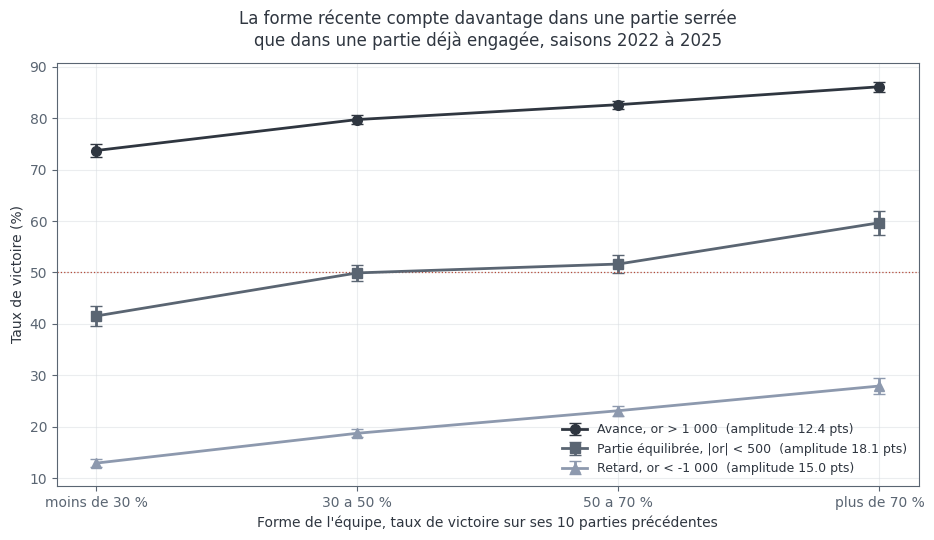

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))

styles = {
    "Avance, or > 1 000": (PALETTE["primary"], "o", "-"),
    "Partie équilibrée, |or| < 500": (PALETTE["secondary"], "s", "-"),
    "Retard, or < -1 000": (PALETTE["accent"], "^", "-"),
}
x = np.arange(len(ETIQUETTES))
for nom, (couleur, marqueur, ligne) in styles.items():
    table = resultats_forme[nom]
    amplitude = 100 * (table["taux"].iloc[-1] - table["taux"].iloc[0])
    ax.errorbar(x, 100 * table["taux"],
                yerr=100 * (table["ic_haut"] - table["ic_bas"]) / 2,
                marker=marqueur, linestyle=ligne, color=couleur, capsize=4,
                linewidth=2, markersize=7,
                label=f"{nom}  (amplitude {amplitude:.1f} pts)")

ax.axhline(50, color=PALETTE["highlight"], linewidth=0.9, linestyle=":")
ax.set_xticks(x)
ax.set_xticklabels(ETIQUETTES)
ax.set_xlabel("Forme de l'équipe, taux de victoire sur ses 10 parties précédentes")
ax.set_ylabel("Taux de victoire (%)")
ax.set_title("La forme récente compte davantage dans une partie serrée\n"
             "que dans une partie déjà engagée, saisons 2022 à 2025",
             fontsize=12, pad=12)
ax.grid(True, alpha=0.5)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(config.FIGURES / "05_forme_et_conversion.png", dpi=150,
            facecolor=PALETTE["background"])
plt.show()

### Insight, recommandation et confiance, question 4

**Insight, et il est contre-intuitif.** La forme récente est bien associée au résultat dans les
trois régimes, mais **son effet est le plus fort dans les parties serrées, pas dans celles où
une avance est déjà prise**. L'amplitude entre une équipe à moins de 30 % de forme et une équipe
à plus de 70 % vaut 18,1 points dans une partie équilibrée, contre 12,4 points seulement quand
l'équipe mène de plus de 1 000 or.

La lecture naturelle, celle du staff qui cherche les équipes qui perdent des parties gagnées,
prédisait l'inverse. Si la forme mesurait une capacité à convertir, l'écart aurait dû être plus
grand dans le régime d'avance, là où il y a justement quelque chose à convertir.

Ce que la forme mesure est donc surtout **le niveau de l'équipe**, pas une compétence de
clôture. Et un avantage économique de 1 000 or **absorbe une partie de l'écart de niveau** :
il ramène une mauvaise équipe à 73,7 % de victoire, ce qu'aucune bonne forme ne lui donnerait
dans une partie serrée.

**Recommandation.** Ne pas construire de coaching sur l'idée de « savoir fermer les parties » à
partir de cet indicateur, il ne l'objective pas. En revanche, l'insight utile pour un staff est
que **l'écart de niveau se joue surtout dans les parties serrées** : c'est là que le travail de
macro et de prise de décision a le plus de valeur marginale.

**Confiance : moyenne.** Les effectifs sont grands et les intervalles étroits, mais la variable
de forme est confondue avec le niveau de l'équipe, et cette analyse ne sépare pas les deux. Une
mesure propre demanderait un indicateur de niveau indépendant, type classement Elo, qui n'est
pas dans les sources du projet.

## 5. Question business 5 : les ligues majeures convertissent-elles mieux ?

### Reformulation

Une équipe de ligue de tier 1 transforme-t-elle une avance de 15 minutes plus souvent qu'une
équipe de tier 3 ? Réciproquement, les remontées sont-elles plus fréquentes dans les ligues
mineures, où le niveau est réputé plus irrégulier ?

- Analyse : taux de conversion d'une avance, taux de remontée, et pente de la courbe de
  conversion par niveau de ligue
- La pente est la mesure la plus complète des trois : elle résume à quel point le résultat est
  déterminé par l'économie de la 15e minute

In [14]:
avance = train[train["golddiffat15"] > 1000]
retard = train[train["golddiffat15"] < -1000]

print("Conversion d'une avance de plus de 1 000 or")
conversion = analyse.taux_victoire(avance, "tier_ligue")
print(conversion.round(4).to_string())
print()
print("Remontee depuis un retard de plus de 1 000 or")
remontee = analyse.taux_victoire(retard, "tier_ligue")
print(remontee.round(4).to_string())
print()

pentes = {}
for tier, sous_ensemble in train.groupby("tier_ligue"):
    p, _ = analyse.pente_or(sous_ensemble)
    pentes[tier] = 100 * p * 1000
    print(f"Tier {tier} : {100 * p * 1000:.2f} points de taux de victoire pour 1 000 or "
          f"({len(sous_ensemble):,} lignes)")

Conversion d'une avance de plus de 1 000 or
            effectif    taux  ic_bas  ic_haut  fiable
tier_ligue                                           
1               3602  0.8009  0.7876   0.8137    True
2              12530  0.8150  0.8081   0.8217    True
3              10777  0.8054  0.7978   0.8128    True

Remontee depuis un retard de plus de 1 000 or
            effectif    taux  ic_bas  ic_haut  fiable
tier_ligue                                           
1               3602  0.1991  0.1863   0.2124    True
2              12530  0.1850  0.1783   0.1919    True
3              10777  0.1946  0.1872   0.2022    True

Tier 1 : 12.83 points de taux de victoire pour 1 000 or (10,968 lignes)
Tier 2 : 13.65 points de taux de victoire pour 1 000 or (35,222 lignes)
Tier 3 : 13.95 points de taux de victoire pour 1 000 or (29,880 lignes)


In [15]:
# Le tier 1 est-il different du tier 3 sur la conversion ?
tier1 = avance[avance["tier_ligue"] == 1]
tier3 = avance[avance["tier_ligue"] == 3]
test = analyse.test_deux_proportions(
    int(tier1["result"].sum()), len(tier1), int(tier3["result"].sum()), len(tier3)
)

print("Test de comparaison tier 1 contre tier 3, conversion d'une avance")
print(f"  Ecart    : {100 * test['ecart']:+.2f} points")
print(f"  z        : {test['z']:.2f}")
print(f"  p-valeur : {test['p_valeur']:.3f}")
conclusion = ("difference significative" if test["p_valeur"] < 0.05
              else "aucune difference significative au seuil de 5 %")
print(f"  Conclusion : {conclusion}")

Test de comparaison tier 1 contre tier 3, conversion d'une avance
  Ecart    : -0.45 points
  z        : -0.59
  p-valeur : 0.558
  Conclusion : aucune difference significative au seuil de 5 %


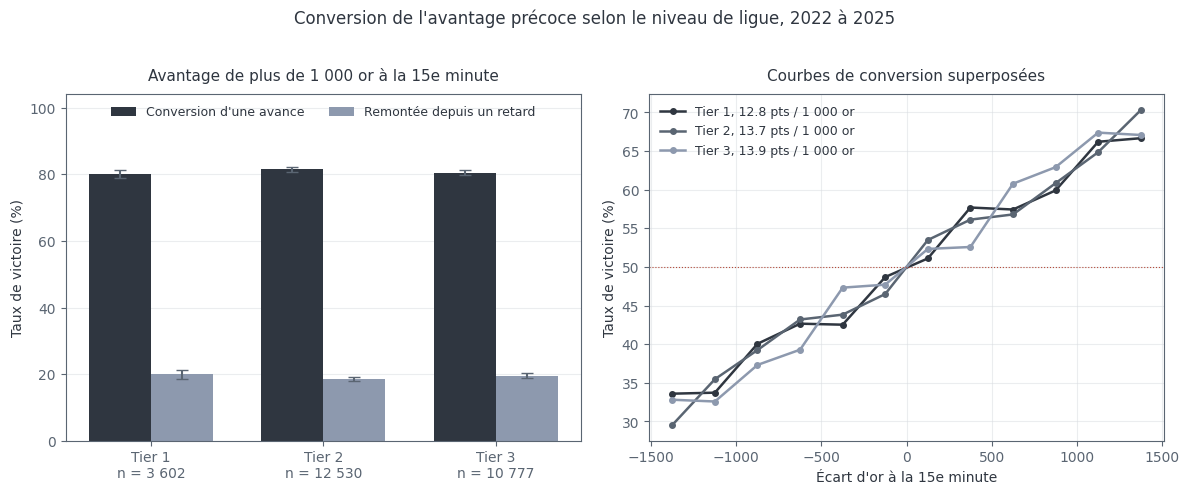

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
tiers = conversion.index.astype(int)
x = np.arange(len(tiers))
largeur = 0.36

ax = axes[0]
ax.bar(x - largeur / 2, 100 * conversion["taux"], largeur, color=PALETTE["primary"],
       label="Conversion d'une avance", capsize=4,
       yerr=100 * (conversion["ic_haut"] - conversion["ic_bas"]) / 2,
       error_kw={"ecolor": PALETTE["secondary"]})
ax.bar(x + largeur / 2, 100 * remontee["taux"], largeur, color=PALETTE["accent"],
       label="Remontée depuis un retard", capsize=4,
       yerr=100 * (remontee["ic_haut"] - remontee["ic_bas"]) / 2,
       error_kw={"ecolor": PALETTE["secondary"]})
ax.set_xticks(x)
ax.set_xticklabels([f"Tier {t}\nn = {fr(n)}" for t, n in zip(tiers, conversion["effectif"])])
ax.set_ylabel("Taux de victoire (%)")
ax.set_ylim(0, 104)
ax.set_title("Avantage de plus de 1 000 or à la 15e minute", fontsize=11, pad=10)
ax.legend(frameon=False, fontsize=9, loc="upper center", ncol=2)
ax.grid(True, axis="y", alpha=0.5)

ax = axes[1]
for tier, sous_ensemble in train.groupby("tier_ligue"):
    _, c = analyse.pente_or(sous_ensemble)
    couleur = [PALETTE["primary"], PALETTE["secondary"], PALETTE["accent"]][int(tier) - 1]
    ax.plot(c["milieu"], 100 * c["taux"], marker="o", markersize=4, color=couleur,
            linewidth=1.8, label=f"Tier {tier}, {pentes[tier]:.1f} pts / 1 000 or")
ax.axhline(50, color=PALETTE["highlight"], linewidth=0.8, linestyle=":")
ax.set_xlabel("Écart d'or à la 15e minute")
ax.set_ylabel("Taux de victoire (%)")
ax.set_title("Courbes de conversion superposées", fontsize=11, pad=10)
ax.legend(frameon=False, fontsize=9)
ax.grid(True, alpha=0.5)

fig.suptitle("Conversion de l'avantage précoce selon le niveau de ligue, 2022 à 2025",
             fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(config.FIGURES / "05_conversion_par_tier.png", dpi=150,
            facecolor=PALETTE["background"], bbox_inches="tight")
plt.show()

### Insight, recommandation et confiance, question 5

**Insight, et c'est un résultat négatif utile.** L'idée reçue selon laquelle les ligues majeures
ferment mieux leurs parties n'est pas vérifiée. Le tier 1 convertit une avance de plus de
1 000 or dans 80,1 % des cas, le tier 2 dans 81,5 %, le tier 3 dans 80,5 %. L'écart entre tier 1
et tier 3 est de 0,4 point, avec une p-valeur de 0,56 : rien de significatif.

Les courbes de conversion se superposent presque, avec des pentes de 12,8, 13,7 et 14,0 points
pour 1 000 or du tier 1 au tier 3. La légère tendance qui se dessine va d'ailleurs **à l'inverse
de l'idée reçue** : le tier 1 est marginalement le moins déterministe, avec un taux de remontée
de 19,9 % contre 18,5 % en tier 2. Les meilleures équipes remontent un peu plus souvent, ce qui
est cohérent avec un niveau de jeu plus élevé mais reste dans le bruit de mesure.

**Recommandation.** Lors d'un recrutement, ne pas décoter les statistiques de conversion d'un
joueur venant d'une ligue mineure : la valeur d'un avantage de 15 minutes est la même partout.
Les écarts entre ligues sont à chercher ailleurs, dans le niveau brut ou la constance, pas dans
la capacité à transformer une avance.

**Confiance : moyenne à élevée** sur les tiers 1 à 3 tels qu'ils sont représentés ici.
**Limite majeure :** la règle de complétude de la phase 3 a fortement réduit la présence de la
LPL dans le jeu d'entraînement, et la Chine n'y pèse que quelques centaines de lignes. Le tier 1
analysé ici est donc surtout coréen, européen et américain. C'est une limite du périmètre, pas
un défaut de la mesure, et elle doit être rappelée à l'oral.

## 6. Découvertes inattendues

Trois résultats n'étaient pas dans les questions de départ.

In [17]:
# 1. Mediation complete du premier sang par l'or
correlation_brute = train["firstblood"].astype(float).corr(train["result"].astype(float))
apport_a_or_egal = valeurs.loc[valeurs["indicateur"] == "firstblood", "ecart_points"].iloc[0]

# 2. La forme pese plus dans les parties serrees que dans les parties engagees
amplitudes = {
    nom: 100 * (t["taux"].iloc[-1] - t["taux"].iloc[0])
    for nom, t in resultats_forme.items()
}

# 3. Part des parties deja decidees a la 15e minute
decide = train[train["golddiffat15"].abs() > 3000]
part_decidee = 100 * len(decide) / len(train)
taux_decide = 100 * decide.loc[decide["golddiffat15"] > 0, "result"].mean()

surprises = pd.DataFrame([
    {
        "decouverte": "Le premier sang est entierement mediatise par l'or",
        "chiffre": f"correlation brute {correlation_brute:.2f}, "
                   f"apport a or egal {apport_a_or_egal:.1f} pt",
        "implication": "Un indicateur tres commente qui n'ajoute rien au modele",
    },
    {
        "decouverte": "La forme pese plus dans une partie serree que dans une partie engagee",
        "chiffre": f"{amplitudes['Partie équilibrée, |or| < 500']:.1f} pts contre "
                   f"{amplitudes['Avance, or > 1 000']:.1f} pts",
        "implication": "La forme mesure le niveau, pas une capacite a conclure",
    },
    {
        "decouverte": "Une minorite de parties est deja jouee a la 15e minute",
        "chiffre": f"{part_decidee:.1f} % des lignes ont plus de 3 000 or d'ecart, "
                   f"converties a {taux_decide:.1f} %",
        "implication": "Le plafond de performance attendu vient des parties serrees",
    },
])
print(surprises.to_string(index=False))

                                                           decouverte                                                             chiffre                                                 implication
                   Le premier sang est entierement mediatise par l'or                     correlation brute 0.20, apport a or egal 0.4 pt     Un indicateur tres commente qui n'ajoute rien au modele
La forme pese plus dans une partie serree que dans une partie engagee                                            18.1 pts contre 12.4 pts      La forme mesure le niveau, pas une capacite a conclure
               Une minorite de parties est deja jouee a la 15e minute 28.2 % des lignes ont plus de 3 000 or d'ecart, converties a 91.8 % Le plafond de performance attendu vient des parties serrees


La troisième mérite un mot, parce qu'elle cadre la phase 7. Les parties très déséquilibrées à
la 15e minute sont peu nombreuses et se prédisent presque toutes correctement. La performance
d'un modèle se joue donc sur la majorité serrée, où l'écart d'or ne tranche pas. C'est une
raison de plus d'attendre un plafond autour de 72 à 78 % d'accuracy, et de se méfier de tout
score qui le dépasserait nettement.

## 7. Synthèse des cinq questions

In [18]:
synthese = pd.DataFrame([
    {
        "n": 1,
        "question": "Quels avantages pesent le plus a 15 minutes ?",
        "insight": "L'or domine, mais seul le premier dragon apporte quelque chose au-dela",
        "chiffre_cle": f"1 000 or = {100 * pente * 1000:.1f} pts ; "
                       f"premier dragon = {valeurs.loc[1, 'or_equivalent']:.0f} or",
        "confiance": "elevee",
        "action": "Prioriser le dragon sur le premier sang a l'entrainement",
    },
    {
        "n": 2,
        "question": "L'avantage du cote bleu existe-t-il encore ?",
        "insight": "Oui, faible mais reel et stable sur quatre saisons",
        "chiffre_cle": f"{100 * bleu['result'].mean():.1f} % "
                       f"[{100 * ic_bas:.1f} ; {100 * ic_haut:.1f}]",
        "confiance": "elevee",
        "action": "Preparer une strategie de draft distincte par cote",
    },
    {
        "n": 3,
        "question": "La composition compte-t-elle a or egal ?",
        "insight": "Aucun effet mesurable avec les tags de Data Dragon",
        "chiffre_cle": f"ecart maximal a 50 % : {ecart_max:.1f} pt, "
                       f"tous les IC contiennent 50 %",
        "confiance": "moyenne",
        "action": "Ne pas arbitrer un pick sur un comptage de tags",
    },
    {
        "n": 4,
        "question": "La forme aide-t-elle a convertir une avance ?",
        "insight": "Non, elle pese davantage dans les parties serrees",
        "chiffre_cle": f"{amplitudes['Partie équilibrée, |or| < 500']:.1f} pts en partie serree "
                       f"contre {amplitudes['Avance, or > 1 000']:.1f} pts en avance",
        "confiance": "moyenne",
        "action": "Cibler le coaching sur les parties serrees",
    },
    {
        "n": 5,
        "question": "Les ligues majeures convertissent-elles mieux ?",
        "insight": "Non, les courbes de conversion se superposent",
        "chiffre_cle": f"tier 1 {100 * conversion.loc[1, 'taux']:.1f} % contre "
                       f"tier 3 {100 * conversion.loc[3, 'taux']:.1f} %, "
                       f"p = {test['p_valeur']:.2f}",
        "confiance": "moyenne a elevee",
        "action": "Ne pas decoter un joueur de ligue mineure sur ce critere",
    },
])

print(synthese.to_string(index=False))

 n                                        question                                                                insight                                                 chiffre_cle        confiance                                                   action
 1   Quels avantages pesent le plus a 15 minutes ? L'or domine, mais seul le premier dragon apporte quelque chose au-dela              1 000 or = 13.6 pts ; premier dragon = 1031 or           elevee Prioriser le dragon sur le premier sang a l'entrainement
 2    L'avantage du cote bleu existe-t-il encore ?                     Oui, faible mais reel et stable sur quatre saisons                                        52.9 % [52.4 ; 53.4]           elevee       Preparer une strategie de draft distincte par cote
 3        La composition compte-t-elle a or egal ?                     Aucun effet mesurable avec les tags de Data Dragon ecart maximal a 50 % : 2.8 pt, tous les IC contiennent 50 %          moyenne          Ne pas arbitrer un pick 

## 8. Validation des conclusions et limites

### Passage de la checklist des signaux d'alerte

| Signal | Vérification effectuée | Verdict |
|---|---|---|
| Résultat trop beau | Aucun taux au-delà de 86 %, et seulement dans le régime d'avance | Rien à signaler |
| Résultat contre-intuitif | Deux cas, questions 4 et 5, tous deux investigués et expliqués | Assumés |
| Corrélation parfaite | Aucune, la plus forte est 0,53 pour l'écart d'or | Rien à signaler |
| Échantillon trop petit | Effectifs affichés partout, groupes sous 100 parties marqués non fiables | Traité |

### Limites communes à toutes les analyses

**Le périmètre n'est pas le circuit complet.** La règle d'inclusion de la phase 3, qui exige un
snapshot complet à 15 minutes sur les deux lignes d'une partie, a écarté une grande partie de
la LPL. Toute conclusion régionale sur la Chine est hors de portée, et le tier 1 analysé est
majoritairement coréen, européen et nord-américain.

**Association n'est pas causalité.** Aucune de ces analyses n'établit un mécanisme causal. Le
contrôle par la bande d'or est un contrôle sur une seule dimension, pas une expérience. La
question 1 en donne l'exemple le plus clair : une partie de la valeur attribuée au premier
dragon vient probablement du niveau de l'équipe qui le prend.

**Le méta évolue.** Quatre saisons couvrent des changements de règles importants, dont l'arrivée
des larves du Néant en 2024 et d'Atakhan en 2025. Les moyennes présentées ici agrègent ces
périodes. La stabilité de l'avantage du côté bleu suggère que ce lissage reste acceptable, mais
il n'est pas vérifié pour chaque indicateur.

**La saison 2026 n'a pas été regardée.** C'est une limite volontaire. Elle interdit toute
affirmation sur l'actualité du méta, et c'est le prix d'une évaluation honnête en phase 7.

### Ce que ces résultats impliquent pour la modélisation

1. Le plafond attendu, 72 à 78 % d'accuracy, est cohérent avec la structure des données. La
   majorité des parties sont serrées à la 15e minute et resteront difficiles.
2. Les variables de composition sont les premières candidates au retrait si elles n'apportent
   rien en interaction.
3. `firstblood` et `firstherald` n'apportent rien au-delà de l'or dans une lecture univariée.
   Ils sont conservés pour l'instant, car un modèle non linéaire peut en tirer parti en
   interaction, mais leur coefficient dans la régression logistique sera à examiner.
4. La régression logistique reste le modèle de référence : les relations observées ici sont
   presque toutes monotones et proches de la linéarité dans la bande utile.

## 9. Export du rapport analytique

In [19]:
def tableau_markdown(df):
    entete = "| " + " | ".join(str(c) for c in df.columns) + " |"
    separateur = "|" + "|".join(["---"] * len(df.columns)) + "|"
    corps = ["| " + " | ".join(str(v) for v in ligne) + " |"
             for ligne in df.itertuples(index=False)]
    return "\n".join([entete, separateur] + corps)


synthese_doc = synthese.rename(columns={
    "n": "#", "question": "Question business", "insight": "Insight principal",
    "chiffre_cle": "Chiffre cle", "confiance": "Confiance", "action": "Action proposee",
})
surprises_doc = surprises.rename(columns={
    "decouverte": "Decouverte", "chiffre": "Chiffre", "implication": "Implication",
})
colonnes_valeurs = ["indicateur", "taux_avec", "taux_sans", "n_avec", "ecart_points",
                    "p_valeur", "or_equivalent"]
amplitude_equilibre = amplitudes["Partie équilibrée, |or| < 500"]
amplitude_avance = amplitudes["Avance, or > 1 000"]
amplitude_retard = amplitudes["Retard, or < -1 000"]

rapport = f"""# Rapport d'analyse, phase 5

Document genere par `notebooks/05_eda_analytique.ipynb`, a ne pas editer a la main.

Donnees fournies par Oracle's Elixir (Tim Sevenhuysen, oracleselixir.com).

## Perimetre

| Propriete | Valeur |
|---|---|
| Lignes analysees | {len(train):,} |
| Parties | {train['gameid'].nunique():,} |
| Periode | {train['date'].min():%Y-%m-%d} au {train['date'].max():%Y-%m-%d} |
| Saisons | {train['saison'].min()} a {train['saison'].max()} |
| Cible | equilibree a {100 * train['result'].mean():.2f} % |
| Saison 2026 | {n_test:,} lignes reservees au test, non ouvertes |

Toutes les analyses sont calculees sur le seul jeu d'entrainement. La saison 2026 est ouverte
une fois, a la fin de la phase 7. La regarder ici reviendrait a choisir des hypotheses en
fonction du jeu de test, et le score final ne mesurerait plus rien.

Chaque taux de victoire est accompagne de son effectif et d'un intervalle de confiance a 95 %
calcule par la methode de Wilson. Quand l'intervalle contient 50 %, la conclusion retenue est
qu'il n'y a rien a conclure.

## Synthese des cinq questions business

{tableau_markdown(synthese_doc)}

## Methode commune aux analyses de contribution

L'ecart d'or a la 15e minute est de tres loin le premier signal disponible. La question posee
pour la plupart des variables n'est donc pas de savoir si elle est associee a la victoire, mais
si elle apporte quelque chose au-dela de l'or.

La methode employee est la meme partout : restreindre l'analyse aux parties ou les deux equipes
sont au coude a coude a la 15e minute. Dans cette bande, l'or n'explique plus rien, et l'ecart
de taux de victoire qui subsiste est un apport propre. La pente locale de la courbe de
conversion, {100 * pente * 1000:.2f} points de taux de victoire pour 1 000 or, permet ensuite de
traduire cet apport en or.

Le controle a ete verifie et non suppose : dans la bande a 500 or, l'ecart d'or moyen de chaque
groupe de composition suffisamment peuple reste a moins de {ecart_or_max:.0f} or de zero.

## Question 1 : hierarchie des avantages a la 15e minute

Classement univarie, AUC sur le jeu d'entrainement :

{tableau_markdown(classement.head(6).round(3))}

Valeur propre des objectifs, mesuree a ecart d'or inferieur a 250 :

{tableau_markdown(affichage[colonnes_valeurs])}

Le premier dragon vaut environ {valeurs.loc[1, 'or_equivalent']:.0f} or. Le premier sang et le
premier heraut ne valent rien de plus que l'or qu'ils rapportent deja, ce qui est coherent avec
la mecanique du jeu : les deux rapportent de l'or, le dragon n'en rapporte aucun.

Figures : `figures/05_conversion_ecart_or.png` et `figures/05_valeur_objectifs_precoces.png`.

## Question 2 : avantage du cote bleu

Taux de victoire du cote bleu sur {len(bleu):,} parties : {100 * bleu['result'].mean():.2f} %,
intervalle de confiance [{100 * ic_bas:.2f} % ; {100 * ic_haut:.2f} %]. L'intervalle ne contient
pas 50 %, l'avantage est reel. Il equivaut a environ
{(bleu['result'].mean() - 0.5) / pente:.0f} or offerts avant le debut de la partie.

Par saison :

{tableau_markdown(par_saison.reset_index().round(4))}

L'avantage est stable, sans tendance, et les intervalles des quatre saisons se recoupent.

Figure : `figures/05_avantage_cote_bleu.png`.

## Question 3 : composition de draft a avantage economique egal

Aucun effet mesurable. Sur les groupes de composition suffisamment peuples, l'ecart maximal au
hasard est de {ecart_max:.2f} points et {100 * contiennent_50:.0f} % des intervalles de
confiance contiennent 50 %. Le controle economique tient : l'ecart d'or moyen de ces groupes
reste a moins de {ecart_or_max:.0f} or de zero.

Ce resultat porte sur cette representation de la composition, un comptage de tags Data Dragon,
et non sur la composition en general. La synergie entre champions et l'ordre de la draft, absent
d'Oracle's Elixir, ne sont pas captures.

## Question 4 : forme recente et conversion d'une avance

Amplitude du taux de victoire entre une equipe a moins de 30 % de forme et une equipe a plus de
70 %, selon le regime de partie :

| Regime | Amplitude |
|---|---|
| Partie equilibree, ecart d'or inferieur a 500 | {amplitude_equilibre:.1f} points |
| Avance de plus de 1 000 or | {amplitude_avance:.1f} points |
| Retard de plus de 1 000 or | {amplitude_retard:.1f} points |

L'effet de la forme est le plus fort dans les parties serrees, pas dans celles ou une avance est
deja prise. La forme mesure donc surtout le niveau de l'equipe, pas une capacite a conclure.

Figure : `figures/05_forme_et_conversion.png`.

## Question 5 : niveau de ligue et conversion

Conversion d'une avance de plus de 1 000 or :

{tableau_markdown(conversion.reset_index().round(4))}

Comparaison tier 1 contre tier 3 : ecart de {100 * test['ecart']:+.2f} point, p-valeur
{test['p_valeur']:.3f}. Aucune difference significative.

Pentes de conversion, en points de taux de victoire pour 1 000 or : tier 1 {pentes[1]:.2f},
tier 2 {pentes[2]:.2f}, tier 3 {pentes[3]:.2f}. La tendance va a l'inverse de l'idee recue, le
tier 1 etant marginalement le moins deterministe.

Figure : `figures/05_conversion_par_tier.png`.

## Decouvertes inattendues

{tableau_markdown(surprises_doc)}

## Limites

- Le perimetre exclut une grande partie de la LPL, consequence de la regle de completude de la
  phase 3. Aucune conclusion regionale sur la Chine n'est possible.
- Association n'est pas causalite. Le controle par la bande d'or porte sur une seule dimension.
- Quatre saisons de meta sont agregees, dont deux changements de regles majeurs.
- La saison 2026 n'a pas ete regardee, limite volontaire.

## Implications pour la phase 7

1. Le plafond attendu de 72 a 78 % d'accuracy est coherent avec la structure des donnees :
   {part_decidee:.1f} % des lignes seulement presentent plus de 3 000 or d'ecart a la 15e minute.
2. Les cinq variables de composition sont les premieres candidates au retrait.
3. `firstblood` et `firstherald` n'apportent rien en univarie a or egal, leur coefficient dans
   la regression logistique sera a examiner.
4. Les relations observees sont presque toutes monotones, ce qui conforte la regression
   logistique comme modele de reference interpretable.
"""

chemin_rapport = config.DOCS / "rapport_analytique.md"
chemin_rapport.write_text(rapport, encoding="utf-8")
print(f"Rapport ecrit : {chemin_rapport}")
print(f"{len(rapport):,} caracteres")
print()
print("Figures produites :")
for figure in sorted(config.FIGURES.glob("05_*.png")):
    print(f"  {figure.name}  ({figure.stat().st_size / 1000:.0f} ko)")

Rapport ecrit : E:\LWP(LoLWinPrediciton)\lol-win-prediction\docs\rapport_analytique.md
8,399 caracteres

Figures produites :
  05_avantage_cote_bleu.png  (96 ko)
  05_conversion_ecart_or.png  (123 ko)
  05_conversion_par_tier.png  (117 ko)
  05_forme_et_conversion.png  (98 ko)
  05_valeur_objectifs_precoces.png  (87 ko)


## 10. Réflexion

**Le résultat le plus surprenant.** Que le premier sang ne vaille rien une fois l'or contrôlé.
C'est l'indicateur le plus commenté par les casteurs, et sa corrélation brute avec la victoire,
0,20, semble lui donner raison. La mesure à or égal montre que cette corrélation n'est que le
reflet des 400 or qu'il rapporte. Le contraste avec le premier dragon, qui ne rapporte aucun or
et vaut pourtant 1 030 or, est le meilleur argument de ce notebook en faveur de l'analyse
conditionnelle.

**Le résultat le plus utile au public cible.** Pour un coach, la question 4 : l'écart de niveau
se joue dans les parties serrées, pas dans la conversion des avances. Pour une plateforme de
statistiques, la question 1 : afficher le premier dragon plutôt que le premier sang.

**La principale limite.** Le contrôle par bande d'or contrôle l'économie, pas le niveau des
équipes. Toutes les valeurs mesurées à or égal sont donc des majorants : elles mélangent la
valeur de l'objectif et la force de l'équipe qui l'a obtenu. Un contrôle propre demanderait un
indicateur de niveau indépendant, absent des sources du projet.

**Ce qui aurait enrichi l'analyse.** L'ordre de la draft, pour la question 3, et un classement
Elo par équipe, pour la question 4. Ni l'un ni l'autre n'existe dans Oracle's Elixir.

**Ce que la phase 6 doit raconter.** Une seule histoire : tous les avantages précoces ne se
valent pas, et le marché de l'attention se trompe de cible. La figure de la valeur des objectifs
est le point d'entrée naturel.